In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from collections import OrderedDict
import gc

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()

print(f"Using device: {device} | GPUs available: {num_gpus}")

Using device: cuda | GPUs available: 2


In [4]:
# --- SETTINGS FOR ANIME DATASET ---
DATASET_CHOICE = "ANIME" 
BATCH_SIZE = 32        # Higher batch size for Dual T4 GPUs
LEARNING_RATE = 2e-4
BETA1 = 0.5
BETA2 = 0.999
EPOCHS = 20            # Anime is large; 20 epochs is usually plenty
IMAGE_SIZE = 256
L1_LAMBDA = 150        # Higher penalty for color accuracy

if DATASET_CHOICE == "ANIME":
    INPUT_DIR = "/kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/train"
    TARGET_DIR = None 
    SINGLE_IMAGE_PAIR = True

In [5]:
class KagglePairedDataset(Dataset):
    def __init__(self, input_dir, target_dir=None, is_single_image=False):
        self.input_dir = input_dir
        self.target_dir = target_dir
        self.is_single_image = is_single_image
        self.all_inputs = sorted([f for f in os.listdir(input_dir) if f.endswith(('.jpg', '.png'))])
        self.normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

    def __len__(self):
        return len(self.all_inputs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.input_dir, self.all_inputs[idx])
        full_img = Image.open(img_path).convert("RGB")
        
        if self.is_single_image:
            # For Anime: Left side is Target (Color), Right side is Input (Sketch)
            w, h = full_img.size
            target_img = full_img.crop((0, 0, w//2, h))
            input_img = full_img.crop((w//2, 0, w, h))
        else:
            # Logic for separate folders (CUHK style)
            input_img = full_img # simplified for this demo
            target_img = Image.open(os.path.join(self.target_dir, self.all_inputs[idx]))
            
        input_img = input_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
        target_img = target_img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
        
        input_tensor = self.normalize(transforms.ToTensor()(input_img))
        target_tensor = self.normalize(transforms.ToTensor()(target_img))
        return input_tensor, target_tensor

dataset = KagglePairedDataset(INPUT_DIR, TARGET_DIR, is_single_image=SINGLE_IMAGE_PAIR)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
print(f"Dataset Loaded: {len(dataset)} image pairs found.")

Dataset Loaded: 14224 image pairs found.


In [6]:
class UNetBlock(nn.Module):
    def __init__(self, in_c, out_c, down=True, use_dropout=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False) if down 
            else nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True) if not down else nn.LeakyReLU(0.2, inplace=True)
        )
        self.dropout = nn.Dropout(0.5) if use_dropout else nn.Identity()

    def forward(self, x):
        return self.dropout(self.conv(x))

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = nn.Conv2d(3, 64, 4, 2, 1, padding_mode="reflect")
        self.down2 = UNetBlock(64, 128)
        self.down3 = UNetBlock(128, 256)
        self.down4 = UNetBlock(256, 512)
        self.up1 = UNetBlock(512, 256, down=False, use_dropout=True)
        self.up2 = UNetBlock(512, 128, down=False)
        self.up3 = UNetBlock(256, 64, down=False)
        self.final_up = nn.Sequential(nn.ConvTranspose2d(128, 3, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1); d3 = self.down3(d2); d4 = self.down4(d3)
        u1 = torch.cat([self.up1(d4), d3], dim=1)
        u2 = torch.cat([self.up2(u1), d2], dim=1)
        u3 = torch.cat([self.up3(u2), d1], dim=1)
        return self.final_up(u3)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1, padding_mode="reflect"),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 1, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 1, padding_mode="reflect")
        )

    def forward(self, x, y):
        return self.model(torch.cat([x, y], dim=1))

In [7]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

if num_gpus > 1:
    generator = nn.DataParallel(generator)
    discriminator = nn.DataParallel(discriminator)

opt_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
bce_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()
scaler = torch.amp.GradScaler('cuda')

In [8]:
def show_samples(input_img, gen_img, target_img, epoch):
    input_img = (input_img[0].detach().cpu().to(torch.float32) * 0.5) + 0.5
    gen_img = (gen_img[0].detach().cpu().to(torch.float32) * 0.5) + 0.5
    target_img = (target_img[0].detach().cpu().to(torch.float32) * 0.5) + 0.5
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(input_img.permute(1, 2, 0).numpy()); ax[0].set_title("Sketch")
    ax[1].imshow(gen_img.permute(1, 2, 0).numpy()); ax[1].set_title(f"Generated (E{epoch})")
    ax[2].imshow(target_img.permute(1, 2, 0).numpy()); ax[2].set_title("Ground Truth")
    plt.show()

Starting Robust Training for ANIME...


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1843


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1779


...


Saved Best Model: 0.1744


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1710


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1693


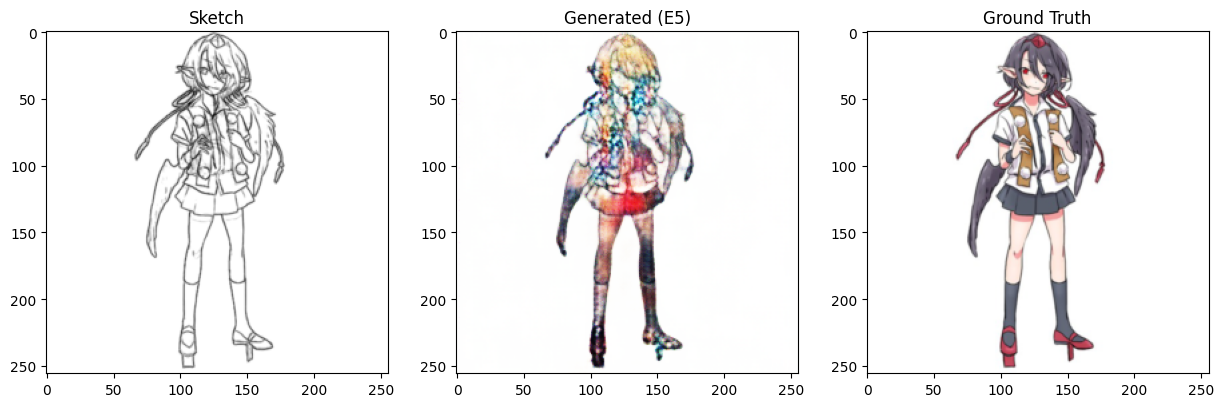

  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1666


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1650


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1631


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1613


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1597


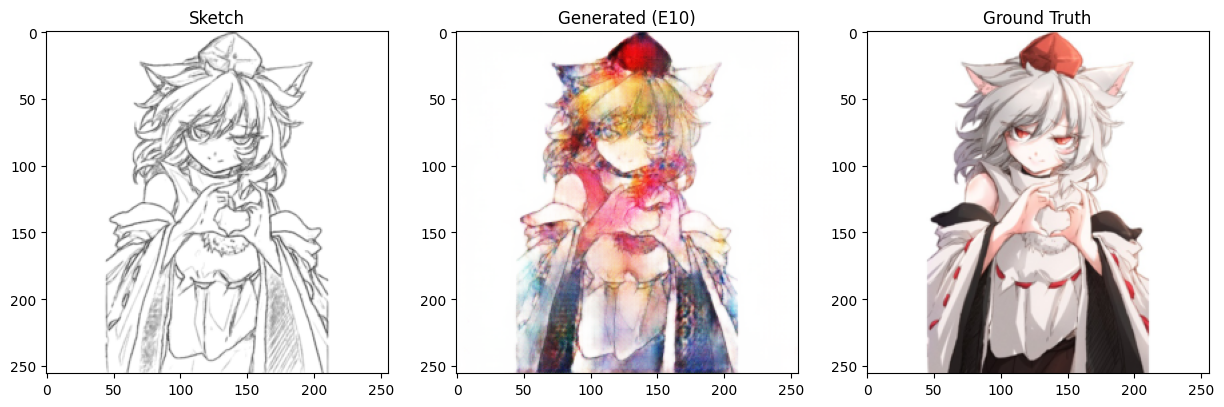

  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1581


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1569


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1554


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1534


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1517


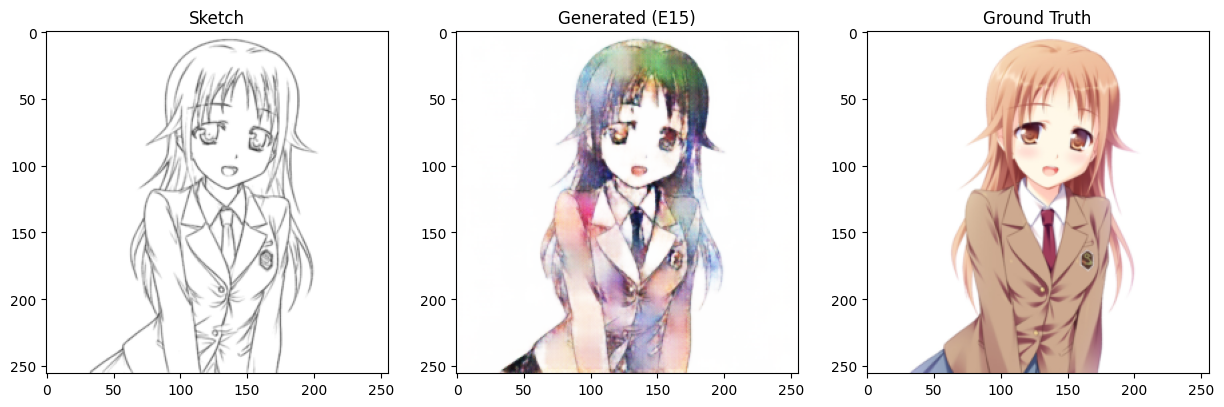

  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1503


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1485


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1475


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1457


  0%|          | 0/445 [00:00<?, ?it/s]


Saved Best Model: 0.1445


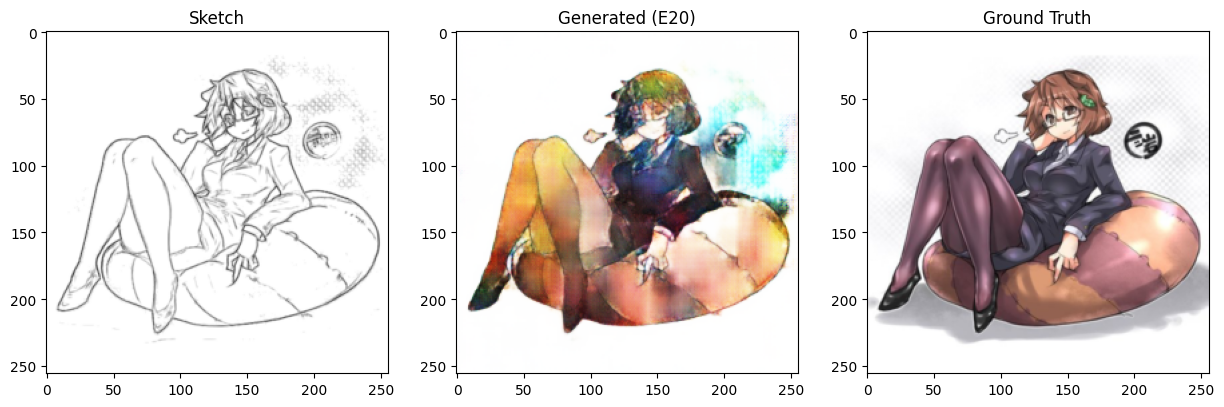

In [13]:
from tqdm.auto import tqdm
import os
import gc

# 1. Clear memory before starting
torch.cuda.empty_cache()
gc.collect()

os.makedirs('checkpoints', exist_ok=True)
best_l1 = float('inf')

# IMPORTANT: Re-initialize the scaler to clear its internal state
scaler = torch.amp.GradScaler('cuda') 

print(f"Starting Robust Training for {DATASET_CHOICE}...")

for epoch in range(EPOCHS):
    epoch_l1 = 0
    loop = tqdm(dataloader, leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
    
    generator.train()
    discriminator.train()

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        
        # --- TRAIN DISCRIMINATOR ---
        opt_D.zero_grad()
        with torch.amp.autocast('cuda'):
            fake_y = generator(x)
            D_real = discriminator(x, y)
            D_fake = discriminator(x, fake_y.detach())
            
            loss_D_real = bce_loss(D_real, torch.ones_like(D_real))
            loss_D_fake = bce_loss(D_fake, torch.zeros_like(D_fake))
            loss_D = (loss_D_real + loss_D_fake) / 2
            
        scaler.scale(loss_D).backward()
        scaler.step(opt_D)
        # Force an update here to clear the 'STEPPED' state
        scaler.update() 
        
        # --- TRAIN GENERATOR ---
        opt_G.zero_grad()
        with torch.amp.autocast('cuda'):
            D_fake_eval = discriminator(x, fake_y)
            loss_G_bce = bce_loss(D_fake_eval, torch.ones_like(D_fake_eval))
            
            current_l1 = l1_loss(fake_y, y)
            loss_G = loss_G_bce + (current_l1 * L1_LAMBDA)
            
        scaler.scale(loss_G).backward()
        scaler.step(opt_G)
        # Update again for the second optimizer
        scaler.update() 
        
        # Tracking
        batch_l1_val = current_l1.item()
        epoch_l1 += batch_l1_val
        loop.set_postfix(D=f"{loss_D.item():.4f}", G=f"{loss_G.item():.4f}", L1=f"{batch_l1_val:.4f}")

    # --- SAVE LOGIC ---
    avg_l1 = epoch_l1 / len(dataloader)
    if avg_l1 < best_l1:
        best_l1 = avg_l1
        torch.save(generator.state_dict(), f'checkpoints/best_{DATASET_CHOICE.lower()}.pth')
        print(f"\nSaved Best Model: {avg_l1:.4f}")

    if (epoch + 1) % 5 == 0:
        show_samples(x, fake_y, y, epoch+1)

In [14]:
psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# Load Best Weights
checkpoint = torch.load('checkpoints/best_anime_generator.pth')
clean_dict = OrderedDict((k.replace('module.', ''), v) for k, v in checkpoint.items())
(generator.module if hasattr(generator, 'module') else generator).load_state_dict(clean_dict)
generator.eval()

# Run Metrics
all_p, all_s = [], []
with torch.no_grad():
    for x, y in dataloader:
        fake = generator(x.to(device))
        all_p.append(psnr((fake*0.5)+0.5, (y.to(device)*0.5)+0.5).item())
        all_s.append(ssim((fake*0.5)+0.5, (y.to(device)*0.5)+0.5).item())

print(f"ANIME RESULTS - PSNR: {sum(all_p)/len(all_p):.2f} | SSIM: {sum(all_s)/len(all_s):.4f}")

ANIME RESULTS - PSNR: 12.54 | SSIM: 0.7255
